In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/tiempoDS.csv.gz')
df

FileNotFoundError: [Errno 2] No such file or directory: '../data/tiempoDS.csv.gz'

In [3]:
# import pandas as pd
# import numpy as np
# from pmdarima.arima import auto_arima
# from joblib import Parallel, delayed
# import warnings
# warnings.filterwarnings("ignore")

# def train_country_robust(country_name, df_country):
#     try:
#         # 1. Preparación y Filtrado Temporal
#         df = df_country.copy()
        
#         # Crear índice datetime
#         df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
#         df.set_index('date', inplace=True)
#         df.sort_index(inplace=True)
        
#         # --- FILTRADO CLAVE: Solo desde 1950 ---
#         df = df[df.index >= '1950-01-01']
        
#         if len(df) < 24: # Mínimo 2 años de datos post-1950
#             return None

#         # Eliminar duplicados de fecha (seguridad)
#         df = df[~df.index.duplicated(keep='first')]
        
#         # Rellenar huecos temporales si faltan meses entre 1950 y ahora
#         full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')
#         df = df.reindex(full_range)
#         df.index.name = 'date'
        
#         # Interpolar valores faltantes
#         df['AvTemp'] = df['AvTemp'].interpolate(method='linear', limit_area='inside')
#         df.dropna(subset=['AvTemp'], inplace=True)
        
#         if len(df) < 24:
#             return None

#         # 2. Entrenamiento SARIMAX
#         model = auto_arima(
#             df['AvTemp'],
#             m=12, seasonal=True,
#             d=None, D=None, 
#             max_p=3, max_q=3,
#             max_P=2, max_Q=2,
#             stepwise=True,
#             suppress_warnings=True,
#             error_action='ignore',
#             trace=False
#         )
        
#         # 3. Predicción (30 años)
#         n_periods = 30 * 12
#         forecast, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)
        
#         last_date = df.index[-1]
#         future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=n_periods, freq='MS')
        
#         df_res = pd.DataFrame({
#             'Country': country_name,
#             'Date': future_dates,
#             'Year': future_dates.year,
#             'Predicted_Temp': forecast,
#             'Conf_Int_Lower': conf_int[:, 0],
#             'Conf_Int_Upper': conf_int[:, 1],
#             'AIC': model.aic()
#         })
        
#         return df_res

#     except Exception as e:
#         return None

# # --- EJECUCIÓN ---
# print("Filtrando datos desde 1950 y procesando...")

# # Asegúrate de que tu DataFrame original se llama 'df'
# grouped = df.groupby('country') 

# results = Parallel(n_jobs=-1, verbose=10)(
#     delayed(train_country_robust)(name, group) 
#     for name, group in grouped
# )

# valid_results = [r for r in results if r is not None]

# if valid_results:
#     final_df = pd.concat(valid_results, ignore_index=True)
#     final_df.to_csv('predicciones_climaticas_1950_plus.csv', index=False)
#     print(f"\n✅ Éxito: {len(valid_results)} países procesados con datos post-1950.")
# else:
#     print("❌ No se generaron predicciones.")

In [4]:
# import pandas as pd
# import numpy as np
# from pmdarima.arima import auto_arima
# from statsmodels.tsa.stattools import adfuller
# from statsmodels.tsa.seasonal import seasonal_decompose
# from joblib import Parallel, delayed
# from tqdm import tqdm # Importamos tqdm para la barra de progreso
# import warnings
# import time

# from tqdm.autonotebook import tqdm as tqdm_notebook
# warnings.filterwarnings("ignore")

In [5]:
# def analyze_and_predict_country(country_name, df_country):
#     try:
#         # 1. Preparación de Datos
#         df = df_country.copy()
#         df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
#         df.set_index('date', inplace=True)
#         df.sort_index(inplace=True)
        
#         # Filtrado Post-1950
#         df = df[df.index >= '1950-01-01']
        
#         if len(df) < 60: 
#             return None

#         # Seguridad mínima para índice único
#         df = df[~df.index.duplicated(keep='first')]
        
#         # Interpolación mínima para continuidad mensual (necesaria para SARIMA/Decompose)
#         full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')
#         df = df.reindex(full_range)
#         df['AvTemp'] = df['AvTemp'].interpolate(method='linear', limit_area='inside')
#         df.dropna(subset=['AvTemp'], inplace=True)

#         if len(df) < 60:
#             return None

#         # 2. Separación Train (1950-1999) / Test (2000-2012)
#         train_data = df[df.index < '2000-01-01']['AvTemp']
#         test_data = df[df.index >= '2000-01-01']['AvTemp']
        
#         if len(train_data) < 24 or len(test_data) < 12:
#             return None

#         # 3. Análisis Estadístico Previo (Sobre Train)
        
#         # A. Estacionariedad (ADF Test)
#         adf_result = adfuller(train_data.dropna())
#         adf_pvalue = adf_result[1]
#         is_stationary = adf_pvalue < 0.05
        
#         # B. Descomposición Estacional
#         try:
#             decomposition = seasonal_decompose(train_data, model='additive', period=12)
#             trend_mean = decomposition.trend.mean()
#             seasonal_strength = decomposition.seasonal.std()
#         except:
#             trend_mean = np.nan
#             seasonal_strength = np.nan

#         # 4. Modelado SARIMA (Entrenamiento)
#         model = auto_arima(
#             train_data,
#             m=12, seasonal=True,
#             d=None, D=None, 
#             max_p=3, max_q=3,
#             max_P=2, max_Q=2,
#             stepwise=True,
#             suppress_warnings=True,
#             error_action='ignore',
#             trace=False
#         )
        
#         order = model.order
#         seasonal_order = model.seasonal_order
#         aic = model.aic()

#         # 5. Validación en Test (2000-2012)
#         forecast_test = model.predict(n_periods=len(test_data))
#         rmse = np.sqrt(np.mean((test_data.values - forecast_test)**2))
#         mae = np.mean(np.abs(test_data.values - forecast_test))
        
#         # --- DEVOLVER RESULTADOS DE VALIDACIÓN (Sin predicción futura) ---
#         df_stats = pd.DataFrame({
#             'Country': [country_name], # Importante: lista para crear fila
#             'RMSE_Test': [rmse],
#             'MAE_Test': [mae],
#             'AIC': [aic],
#             'Model_Order': [str(order)],
#             'Seasonal_Order': [str(seasonal_order)],
#             'ADF_PValue': [adf_pvalue],
#             'Is_Stationary': [is_stationary],
#             'Trend_Mean_Train': [trend_mean],
#             'Seasonal_Strength': [seasonal_strength]
#         })
        
#         return df_stats
    
#         # # 6. Predicción Futura (Reentrenamiento con TODOS los datos 1950-2012)
#         # model_final = auto_arima(
#         #     df['AvTemp'],
#         #     m=12, seasonal=True,
#         #     order=order, seasonal_order=seasonal_order,
#         #     stepwise=False,
#         #     suppress_warnings=True,
#         #     error_action='ignore'
#         # )
        
#         # n_periods_future = 30 * 12
#         # forecast_future, conf_int = model_final.predict(n_periods=n_periods_future, return_conf_int=True)
        
#         # last_date = df.index[-1]
#         # future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=n_periods_future, freq='MS')
        
#         # # 7. Construcción del Resultado
#         # df_res = pd.DataFrame({
#         #     'Country': country_name,
#         #     'Date': future_dates,
#         #     'Year': future_dates.year,
#         #     'Predicted_Temp': forecast_future,
#         #     'Conf_Int_Lower': conf_int[:, 0],
#         #     'Conf_Int_Upper': conf_int[:, 1],
#         #     'RMSE_Test': rmse,
#         #     'MAE_Test': mae,
#         #     'AIC': aic,
#         #     'Model_Order': str(order),
#         #     'Seasonal_Order': str(seasonal_order),
#         #     'ADF_PValue': adf_pvalue,
#         #     'Is_Stationary': is_stationary,
#         #     'Trend_Mean_Train': trend_mean,
#         #     'Seasonal_Strength': seasonal_strength
#         # })
        
#         # return df_res

#     except Exception as e:
#         print(f"Error en {country_name}: {e}")
#         return None
    
# # --- EJECUCIÓN CON BARRA DE PROGRESO ---
# print("Iniciando análisis estadístico y validación (Fase 1)...")

# grouped = df.groupby('country') 
# countries_list = list(grouped.groups.keys())
# total_countries = len(countries_list)

# # Ejecución paralela monitorizada
# results = Parallel(n_jobs=-1, backend='loky')(
#     delayed(analyze_and_predict_country)(name, group) 
#     for name, group in tqdm(grouped, total=total_countries, desc="Clima ML")
# )

# valid_results = [r for r in results if r is not None]

# if valid_results:
#     # Concatenar los DataFrames de estadísticas
#     stats_df = pd.concat(valid_results, ignore_index=True)
    
#     # Guardar resumen de calidad del modelo
#     stats_df.to_csv('resumen_validacion_modelos.csv', index=False)
    
#     print(f"\n✅ Éxito: {len(valid_results)} países analizados.")
#     print("\n--- Resumen de Validación (Test 2000-2012) ---")
#     print(f"RMSE Promedio: {stats_df['RMSE_Test'].mean():.4f}")
#     print(f"MAE Promedio: {stats_df['MAE_Test'].mean():.4f}")
    
#     # Mostrar los 5 peores modelos
#     print("\n⚠️ Top 5 países con mayor error (RMSE):")
#     print(stats_df[['Country', 'RMSE_Test', 'ADF_PValue']].sort_values(by='RMSE_Test', ascending=False).head())
    
# else:
#     print("❌ No se generaron resultados válidos.")

RMSE Promedio (2.62°C): Es un valor aceptable para temperaturas mensuales a nivel global, considerando la variabilidad natural del clima. Significa que, de media, el modelo se equivoca en ±2.6 grados al predecir meses que "ya han ocurrido" (2000-2012) usando solo datos antiguos.
Los "Outliers" (Top 5 Errores):

   * Rusia, China, Kazajistán, Irán: Son países masivos con climas continentales extremos. Un solo promedio nacional (AvTemp) para toda Rusia es estadísticamente muy difícil de modelar porque mezcla el Ártico con el subtópico. El alto RMSE aquí no significa necesariamente que el modelo sea malo, sino que la serie temporal es muy "ruidosa" o heterogénea.
   * Jamaica: Al ser tropical, tiene menos estacionalidad térmica pero mucha influencia de fenómenos como huracanes o El Niño, que son difíciles de capturar solo con SARIMA.

ADF P-Value: Todos son extremadamente bajos (< 0.05). Esto confirma que las series son estacionarias después de las diferencias que aplicó auto_arima (o que la tendencia es muy fuerte y el modelo la está gestionando bien).

In [6]:
import pandas as pd
import numpy as np
from pmdarima.arima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose
from joblib import Parallel, delayed, dump, load
from tqdm import tqdm
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# Crear carpeta para guardar los modelos
MODEL_DIR = "../modelos/modelos_climaticos_sarima"
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)

In [7]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

def isolate_components_manually(series):
    """
    Aísla Tendencia, Estacionalidad y Residuos usando Media Móvil y ADF.
    """
    # 1. Calcular Tendencia con Media Móvil Centrada (CMA) de 12 meses
    # Usamos 'center=True' para alinear la media con el mes central
    trend = series.rolling(window=12, center=True).mean()
    
    # La media móvil pierde los primeros y últimos 6 meses. Los rellenamos con extrapolación lineal
    trend = trend.interpolate(method='linear', limit_area='inside')
    
    # 2. Detrended Series (Serie sin tendencia)
    detrended = series - trend
    
    # 3. Verificar Estacionariedad (ADF Test) sobre la serie destendenciada
    adf_result = adfuller(detrended.dropna())
    is_stationary = adf_result[1] < 0.05
    adf_pvalue = adf_result[1]
    
    # 4. Aislar Estacionalidad (Promedio por mes)
    # Creamos un DataFrame temporal para calcular la media de cada mes (Enero, Febrero...)
    temp_df = pd.DataFrame({'date': detrended.index, 'value': detrended.values})
    temp_df['month'] = temp_df['date'].dt.month
    seasonal_pattern = temp_df.groupby('month')['value'].mean().to_dict()
    
    # Aplicamos el patrón estacional a toda la serie
    seasonal = temp_df['month'].map(seasonal_pattern).values
    
    # 5. Residuos (Ruido)
    residuals = detrended - seasonal
    
    return {
        'trend': trend,
        'detrended': detrended,
        'seasonal': seasonal,
        'residuals': residuals,
        'adf_pvalue': adf_pvalue,
        'is_stationary': is_stationary
    }

In [8]:
from pmdarima.arima import auto_arima
from sklearn.linear_model import LinearRegression
import os
import joblib

MODEL_DIR = "modelos_climaticos_hibridos"
if not os.path.exists(MODEL_DIR): os.makedirs(MODEL_DIR)

def train_country_hybrid(country_name, df_country):
    try:
        # 1. Preparación
        df = df_country.copy()
        df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
        df.set_index('date', inplace=True)
        df.sort_index(inplace=True)
        df = df[df.index >= '1950-01-01']
        
        if len(df) < 60: return None
        
        df = df[~df.index.duplicated(keep='first')]
        full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')
        df = df.reindex(full_range)
        df['AvTemp'] = df['AvTemp'].interpolate(method='linear', limit_area='inside')
        df.dropna(subset=['AvTemp'], inplace=True)
        if len(df) < 60: return None

        series = df['AvTemp']
        
        # 2. AISLAR COMPONENTES MANUALMENTE
        components = isolate_components_manually(series)
        trend = components['trend']
        residuals_seasonal = components['detrended'] # Esto incluye estacionalidad + ruido
        
        # 3. Split Train/Test (Sobre la serie destendenciada)
        train_data = residuals_seasonal[residuals_seasonal.index < '2000-01-01']
        test_data_detrended = residuals_seasonal[residuals_seasonal.index >= '2000-01-01']
        test_trend = trend[trend.index >= '2000-01-01']
        test_real = series[series.index >= '2000-01-01']
        
        if len(train_data) < 24: return None

        # 4. Entrenar SARIMA sobre la parte Estacional+Residuo
        # Al quitar la tendencia manual, el modelo se centra en aprender la forma de la curva anual
        model = auto_arima(
            train_data.dropna(), 
            m=12, seasonal=True,
            stepwise=True, suppress_warnings=True, error_action='ignore'
        )
        
        # 5. Validación en Test
        forecast_detrended = model.predict(n_periods=len(test_data_detrended))
        
        # Reconstruir predicción final: Predicción SARIMA + Tendencia Real del periodo test
        forecast_final = forecast_detrended + test_trend.values
        
        rmse = np.sqrt(np.mean((test_real.values - forecast_final)**2))
        
        # 6. Guardar Modelo Híbrido
        safe_name = country_name.replace(" ", "_").replace("/", "_")
        path = os.path.join(MODEL_DIR, f"{safe_name}.joblib")
        
        artifact = {
            'model_sarima': model,
            'last_trend_index': len(trend),
            'rmse': rmse,
            'adf_pvalue': components['adf_pvalue'],
            # Para graficar
            'test_dates': test_real.index.tolist(),
            'test_pred': forecast_final.tolist(),
            'test_real': test_real.values.tolist()
        }
        joblib.dump(artifact, path)
        
        return {'Country': country_name, 'RMSE': rmse, 'Path': path}

    except Exception as e:
        print(f"Error en {country_name}: {e}")
        return None

In [9]:
print("Iniciando entrenamiento robusto con destendencia y guardado...")

grouped = df.groupby('country')
total_countries = len(list(grouped.groups.keys()))

results = Parallel(n_jobs=-1, backend='loky')(
    delayed(train_country_hybrid)(name, group) 
    for name, group in tqdm(grouped, total=total_countries, desc="Entrenando Países")
)

valid_results = [r for r in results if r is not None]

if valid_results:
    metrics_df = pd.DataFrame(valid_results)
    metrics_df.to_csv('metricas_modelos_guardados.csv', index=False)
    
    print(f"\n✅ Éxito: {len(valid_results)} modelos entrenados y guardados en '{MODEL_DIR}'")
    
    # Mostrar mejores y peores
    print("\n--- Top 5 MEJORES Modelos (Menor RMSE) ---")
    print(metrics_df.sort_values(by='RMSE').head())
    
    print("\n--- Top 5 PEORES Modelos (Mayor RMSE) ---")
    print(metrics_df.sort_values(by='RMSE', ascending=False).head())
else:
    print("❌ No se generaron modelos.")

Iniciando entrenamiento robusto con destendencia y guardado...


Entrenando Países: 100%|██████████| 158/158 [21:11<00:00,  8.05s/it]



✅ Éxito: 157 modelos entrenados y guardados en 'modelos_climaticos_hibridos'

--- Top 5 MEJORES Modelos (Menor RMSE) ---
         Country      RMSE                                            Path
31    Costa Rica  0.272884   modelos_climaticos_hibridos\Costa_Rica.joblib
58        Guyana  0.293089       modelos_climaticos_hibridos\Guyana.joblib
132     Suriname  0.293428     modelos_climaticos_hibridos\Suriname.joblib
80       Liberia  0.317633      modelos_climaticos_hibridos\Liberia.joblib
113  Puerto Rico  0.322115  modelos_climaticos_hibridos\Puerto_Rico.joblib

--- Top 5 PEORES Modelos (Mayor RMSE) ---
         Country       RMSE                                            Path
74    Kazakhstan  11.843294   modelos_climaticos_hibridos\Kazakhstan.joblib
117       Russia  11.208847       modelos_climaticos_hibridos\Russia.joblib
24        Canada   9.669057       modelos_climaticos_hibridos\Canada.joblib
0    Afghanistan   8.897747  modelos_climaticos_hibridos\Afghanistan.joblib
66   

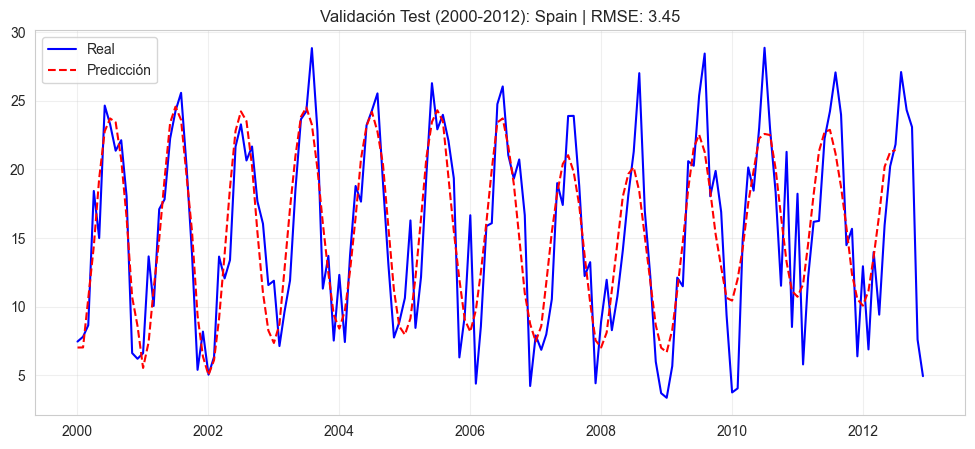

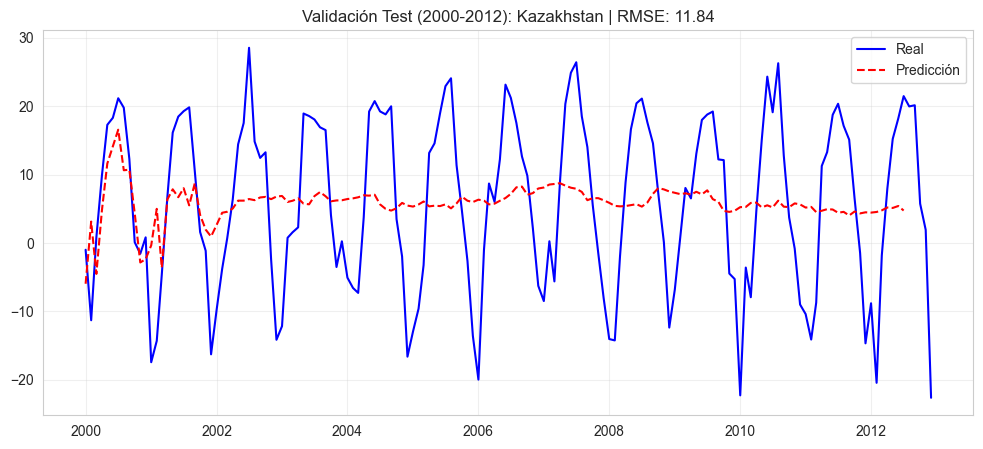

In [10]:
import matplotlib.pyplot as plt
import joblib
import os

def plot_validated_country(country_name):
    safe_name = country_name.replace(" ", "_").replace("/", "_")
    path = os.path.join(MODEL_DIR, f"{safe_name}.joblib")
    
    if not os.path.exists(path):
        print("Modelo no encontrado.")
        return
        
    data = joblib.load(path)
    
    plt.figure(figsize=(12, 5))
    plt.plot(pd.to_datetime(data['test_dates']), data['test_real'], label='Real', color='blue')
    plt.plot(pd.to_datetime(data['test_dates']), data['test_pred'], label='Predicción', color='red', linestyle='--')
    plt.title(f"Validación Test (2000-2012): {country_name} | RMSE: {data['rmse']:.2f}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Ejemplo de revisión:
plot_validated_country('Spain')      # Debería verse muy bien ajustado
plot_validated_country('Kazakhstan') # Aquí verás claramente las limitaciones del modelo

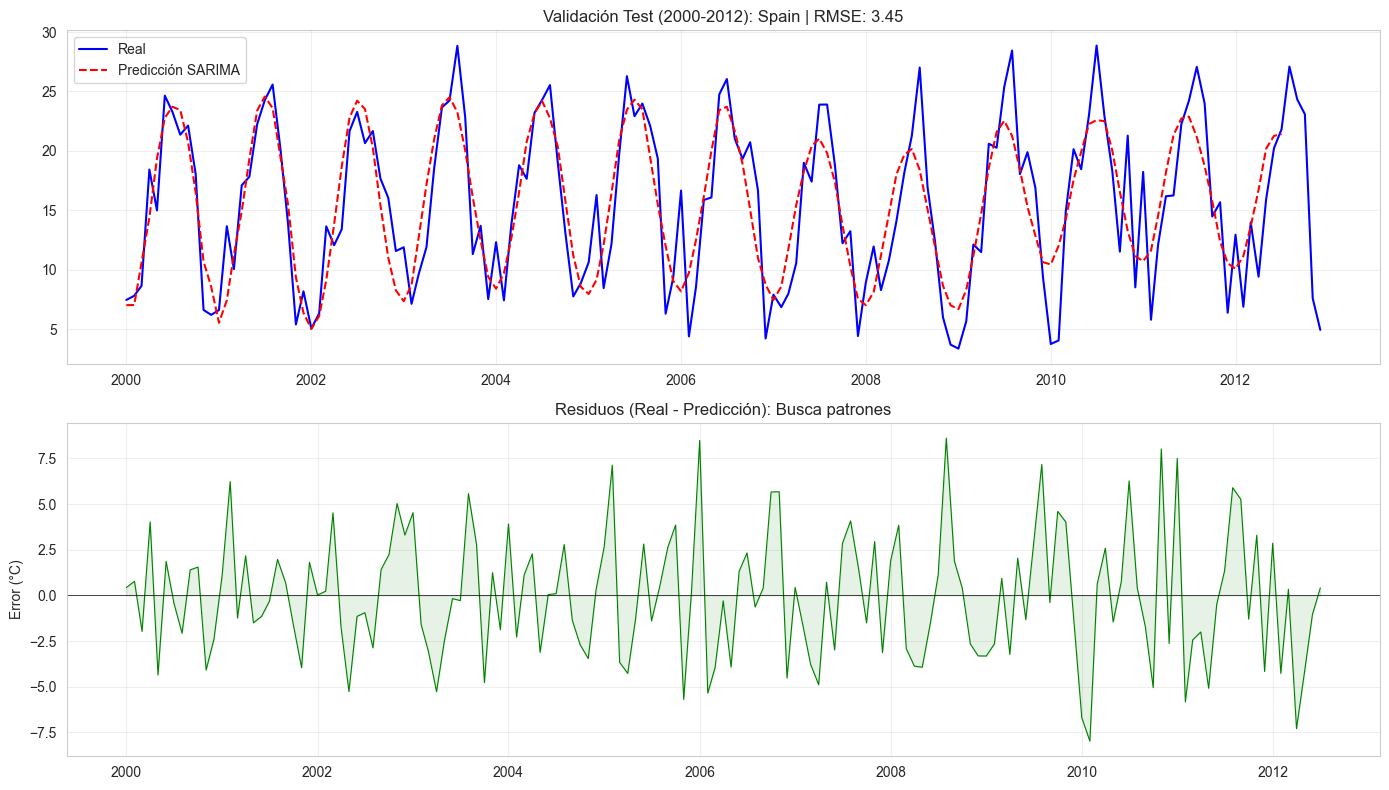

--- Estadísticas de Error para Spain ---
Bias (Sesgo medio): nan °C
Error Máximo: nan °C
Correlación Real-Pred: nan


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib
import os

def plot_diagnosis_detailed(country_name):
    safe_name = country_name.replace(" ", "_").replace("/", "_")
    path = os.path.join(MODEL_DIR, f"{safe_name}.joblib")
    
    if not os.path.exists(path):
        print("Modelo no encontrado.")
        return
        
    data = joblib.load(path)
    dates = pd.to_datetime(data['test_dates'])
    real = np.array(data['test_real'])
    pred = np.array(data['test_pred'])
    residuals = real - pred
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # 1. Comparativa Real vs Predicho
    axes[0].plot(dates, real, label='Real', color='blue', linewidth=1.5)
    axes[0].plot(dates, pred, label='Predicción SARIMA', color='red', linestyle='--', linewidth=1.5)
    axes[0].set_title(f'Validación Test (2000-2012): {country_name} | RMSE: {data["rmse"]:.2f}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Análisis de Residuos (Errores)
    axes[1].plot(dates, residuals, color='green', linewidth=0.8)
    axes[1].axhline(0, color='black', linestyle='-', linewidth=0.5)
    axes[1].fill_between(dates, 0, residuals, color='green', alpha=0.1)
    axes[1].set_title('Residuos (Real - Predicción): Busca patrones')
    axes[1].set_ylabel('Error (°C)')
    axes[1].grid(True, alpha=0.3)
    
    # Añadir líneas de referencia para ver si el error es estacional
    axes[1].axhline(np.mean(residuals), color='orange', linestyle=':', label=f'Bias Medio: {np.mean(residuals):.2f}')
    
    plt.tight_layout()
    plt.show()
    
    # Imprimir estadísticas clave
    print(f"--- Estadísticas de Error para {country_name} ---")
    print(f"Bias (Sesgo medio): {np.mean(residuals):.2f} °C")
    print(f"Error Máximo: {np.max(np.abs(residuals)):.2f} °C")
    print(f"Correlación Real-Pred: {np.corrcoef(real, pred)[0,1]:.4f}")

# Ejecutar para España
plot_diagnosis_detailed('Spain')